In [291]:
import os
import fitz
from bs4 import BeautifulSoup
import requests
import fitz
from io import BytesIO
import pdfplumber
import time 


from supabase.client import Client, create_client
from langchain_groq import ChatGroq 
from sentence_transformers import SentenceTransformer

from langgraph.graph import StateGraph,START, END
from pydantic import BaseModel, Field # for defining structured output for models
import operator

from typing import List, TypedDict, Literal, Annotated, Optional
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain.chains import RetrievalQA

from langchain_core.messages import SystemMessage, HumanMessage

from langchain.output_parsers import PydanticOutputParser
from langchain.prompts import PromptTemplate

from supabase.client import Client, create_client

import warnings
warnings.filterwarnings('ignore')

In [292]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

## process the UOS student handbook 2025-2026 from Top Level Agent

In [293]:
def bookPdfDataProcessor(BookPath): 
    uoshandBook = fitz.open(BookPath)

    Book_contentInner = []
    page_contentInnder = ""

    for page_num, page in enumerate(uoshandBook):
        blocks = page.get_text("blocks")

        for block in blocks:         
            tempCont = block[4].replace("\n", "")
            tempCont = tempCont.replace("\t", " ")
            tempCont = tempCont.replace("\xad", " ") 
            page_contentInnder = page_contentInnder + tempCont

            if len(page_contentInnder.split(" "))>250: 
                Book_contentInner.append(page_contentInnder)
                page_contentInnder = ""

    if len(page_contentInnder.split(" "))>50:
        Book_contentInner.append(page_contentInnder)
        page_contentInnder = ""

    return Book_contentInner


Book_content = bookPdfDataProcessor("./UOS Faculty Handbook 25-26 Design.pdf") + bookPdfDataProcessor("./Student Handbook.pdf")
    
print(min([len(x.split(" ")) for x in Book_content]), max([len(x.split(" ")) for x in Book_content]), sum([len(x.split(" ")) for x in Book_content])/len([len(x.split(" ")) for x in Book_content]))

139 715 299.55280898876407


### Now tokenize these texts and create a vector DB to store them

In [294]:
topLevelAgent_QNA_vectorStore = FAISS.from_texts(Book_content, embeddings)
topLevelAgent_QNA_retriver = topLevelAgent_QNA_vectorStore.as_retriever(search_kwargs={"k":10})

In [295]:
qa_chain_cs_docs = topLevelAgent_QNA_retriver.get_relevant_documents("what department are in College of computing and informatics? ")
# qa_chain_cs_docs = "\n\n".join([d.page_content for d in qa_chain_cs_docs])

qa_chain_cs_docs_modSnet = []
for sent in qa_chain_cs_docs: 
    for word in sent.page_content.split(" "): 
        if word == " " or word=="\t": 
            continue
        else: 
            qa_chain_cs_docs_modSnet.append(word)
        if len(qa_chain_cs_docs_modSnet)>2000: 
            break


qa_chain_cs_docs = " ".join(qa_chain_cs_docs_modSnet)
print(len(qa_chain_cs_docs.split(" ")))

2004


## define the state for the model

In [296]:
class UOS_AgentState(BaseModel): 
    uid: str
    mensOrWomCampus: Literal['mens', 'womens']
    standing: Literal["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
    yearOfStudy: Literal[1,2,3,4,5]
    semester: Literal[1,2,3,4,5,6,7,8,9,10]
    college: Literal[
        "College of Science", 
        "College of Computing and Informatics"
    ]
    department: Literal[
        "BSc_Mathematics", 
        "BSc_Chemistry", 
        "BSc_Petroleum_Geosciences_and_Remote_Sensing", 
        "BSc_Biotechnology", 
        "BSc_Business_Information_Systems", 
        "BSc_IT_Multimedia", 
        "BSc_Computer_Science", 
        "BSc_Cybersecurity", 
        "BSc_Computer_Engineering",
        "BSc_Applied_Physics"
    ]
    studentAlreadyCompletedCourses : List[str] =[]
    StudentAlreadyCompletedCredits : int = 0
    student_query : str

    # agent decision states: below None is for just for redundancy
    UOS_AgentState_top_level_decision: Literal["ScienceAgent", "CCIAgent"] = None
    topLevelAgent_basicConversationOrNot: bool = None
    basic_Conversation_answer : str = None

    # CCI agent states
    UOS_AgentState_CCIAgent_decision: Literal["CCI_Conversation", "CCI_CourseScheduling_advising"] = None
    CCI_weblink_state : str = None
    CCI_weblink_Content : str = None
    CCI_Basic_QNA_RAG_Answer: str = None

    CCI_Course_Core_Study_Plan: List = []
    CCI_Course_Elective_Study_Plan: List = []
    CCI_Offered_Courses_this_semester: List = []

    CCI_to_Science_Communication: bool = False 
    CCI_to_Medical_communication: bool = False 
    CCI_to_OtherCollge_Communication: bool = False
    CCI_FinalScheduler_texts_LLM: str = None




    # Science agent States
    UOS_AgentState_ScienceAgent_decision: Literal["Science_Conversation", "Science_CourseScheduling_advising"] = None
    Science_weblink_state : str = None
    Science_weblink_Content : str = None
    Science_Basic_QNA_RAG_Answer: str = None

    Science_Course_Core_Study_Plan: List = []
    Science_Course_Elective_Study_Plan: List = []
    Science_Offered_Courses_this_semester: List = []

    Science_to_CCI_Communication: bool = False 
    Science_to_Medical_communication: bool = False 
    Science_to_OtherCollge_Communication: bool = False
    Science_FinalScheduler_texts_LLM: str = None

    # Medical College course for student
    Medical_College_Offered_courses: List = []
    # Other all Colleges Offered Courses for Student
    Other_College_Offered_Courses: List = []




### define the structured schemas 

In [297]:
class UOS_AgentState_top_level(BaseModel):
    basicConversationOrNot: bool = Field(
        description="True if the student is engaging in general conversation, False if the user is asking about academic advising or course scheduling or course registering."
    )
    academicAdvising: Optional[Literal["ScienceAgent", "CCIAgent"]] = Field(
        description="ScienceAgent if the user is from College of Science, CCIAgent if the user is from College of Computing and Informatics. Null if not applicable."
    )


class UOS_AgentState_CCI(BaseModel):
    conditionalStateGetter: Optional[Literal[
        "CCI_Conversation",
        "CCI_CourseScheduling_advising"
    ]] = Field(
        ...,
        description=(
            "'CCI_Conversation' if the student is engaging in general conversation and course related questions about the College of Computing and Informatics. "
            "If the student is asking about course scheduling or academic advising for this semester then return 'CCI_CourseScheduling_advising'."
        )
    )


class UOS_AgentState_Science(BaseModel):
    conditionalStateGetter: Optional[Literal[
        "Science_Conversation",
        "Science_CourseScheduling_advising"
    ]] = Field(
        ...,
        description=(
            "'Science_Conversation' if the student is engaging in general conversation and course related questions about the College of Science."
            "If the student is asking about course scheduling or academic advising for this semester then return 'Science_CourseScheduling_advising'."
        )
    )

### Create a CCI-Agent bottom 3 Nodes

In [298]:
class UOS_CCI_website_Link_getter(BaseModel): 
    conditionalStateGetter: Optional[Literal[
        "B_Sc_Computer_Engineering",
        "B_Sc_Cybersecurity_Engineering",
        "B_Sc_Information_Technology_Multimedia",
        "B_Sc_Computer_Science",
        "B_Sc_Biomedical_Informatics",
        "B_Sc_Minor_in_AI",
        "B_Sc_Business_Information_system"
    ]] = Field(
        ...,
        description="Select which state to return. Must be one of the predefined values."
    )


### Create a Science-Agent bottom 3 Nodes

In [299]:
class UOS_Science_website_Link_getter(BaseModel): 
    conditionalStateGetter: Optional[Literal[
        "B_Sc_Bio_Technology",
        "B_Sc_Petroleum_Geoscience_and_Remote_Sensing",
        "B_Sc_Applied_Physics",
        "B_Sc_Chemistry",
        "B_Sc_MatheMatics"
    ]] =  Field(
        ...,
        description="Select which state to return. Must be one of the predefined values."
    )



In [ ]:
groq_api_key = ""

generator_llm = ChatGroq(
    api_key = groq_api_key, 
    model_name = "meta-llama/llama-4-scout-17b-16e-instruct", # "meta-llama/llama-4-scout-17b-16e-instruct"  "llama-3.1-8b-instant",
    temperature = 0,
    max_completion_tokens = 5000,
    top_p = 1.0,
    stream = False,
    stop = None,
    # include_reasoning  = False
)


supabase_key  = ""
supabase_url  = ""
supabaseClient = create_client(supabase_url, supabase_key)

In [301]:
## make the model structured
topLevel_Parser = PydanticOutputParser(pydantic_object=UOS_AgentState_top_level)
topLevel_Agent_prompt = PromptTemplate(
    template=(
        "You are an AI academic advisor and general conversation assistant for the University of Sharjah.\n"
        "Your role is to identify the *type* of query a student is making — whether it is a general/basic conversation, "
        "or an academic/advising query related to their college or department.\n\n"

        "=== UNIVERSITY INFORMATION ===\n"
        "COLLEGE OF SCIENCE includes:\n"
        " - Department of Applied Biology → B.Sc in Biotechnology\n"
        " - Department of Chemistry → B.Sc in Chemistry\n"
        " - Department of Mathematics → B.Sc in Mathematics\n"
        " - Department of Applied Physics and Astronomy → B.Sc in Petroleum Geosciences and Remote Sensing, B.Sc in Applied Physics\n\n"

        "COLLEGE OF COMPUTING AND INFORMATICS includes:\n"
        " - Department of Computer Engineering → B.Sc in Computer Engineering, B.Sc in Cybersecurity Engineering\n"
        " - Department of Computer Science → B.Sc in Computer Science, B.Sc in Information Technology Multimedia, B.Sc in Biomedical Informatics\n"
        " - Department of Information Systems → B.Sc in Business Information Systems\n\n"

        "=== YOUR TASK ===\n"
        "Analyze the student's query and classify it into one of the following categories:\n\n"
        "1. **General/Basic Conversation** — The query is casual, social, or unrelated to academics, course registration, or specific colleges.\n"
        "   → Set `basicConversationOrNot = True`\n"
        "   → Set `academicAdvising = null`\n\n"

        "2. **Academic or College-Specific Query** — The query is about academic advising, course registration, or specifically mentions a college or department.\n"
        "   → Set `basicConversationOrNot = False`\n"
        "   → Determine which college it belongs to:\n"
        "      - If the query is related to the *College of Science*, set `academicAdvising = 'ScienceAgent'`\n"
        "      - If the query is related to the *College of Computing and Informatics*, set `academicAdvising = 'CCIAgent'`\n\n"

        "=== EXAMPLES ===\n"
        "Example 1:\n"
        "Query: 'Hello, how are you today?'\n"
        "→ basicConversationOrNot = True\n"
        "→ academicAdvising = null\n\n"

        "Example 2:\n"
        "Query: 'Can you help me register my courses for this semester in Computer Science?'\n"
        "→ basicConversationOrNot = False\n"
        "→ academicAdvising = 'CCIAgent'\n\n"

        "Example 3:\n"
        "Query: 'What are the available electives in Chemistry this semester?'\n"
        "→ basicConversationOrNot = False\n"
        "→ academicAdvising = 'ScienceAgent'\n\n"

        "Example 4:\n"
        "Query: 'Tell me more about campus clubs and activities.'\n"
        "→ basicConversationOrNot = True\n"
        "→ academicAdvising = null\n\n"

        "=== ADDITIONAL RULES ===\n"
        "- If the query is unclear or outside your domain knowledge, default to `basicConversationOrNot = True` and summarize the intent briefly.\n"
        "- Always select exactly one category.\n"
        "- Never include explanations or reasoning outside the structured format.\n\n"

        "Student is currently enrolled in:\n"
        " - College: {Student_college}\n"
        " - Department: {student_department}\n\n"

        "STUDENT QUERY:\n"
        "{query}\n\n"

        "{format_instructions}\n"
        "DO NOT INCLUDE ANY TEXT OUTSIDE THE REQUIRED FORMAT."
    ),
    input_variables=["Student_college", "student_department", "query"],
    partial_variables={"format_instructions": topLevel_Parser.get_format_instructions()}
)

topLevel_Agent_chain = topLevel_Agent_prompt | generator_llm | topLevel_Parser



In [302]:
# CCI related Agents and Processor
CCI_Parser = PydanticOutputParser(pydantic_object=UOS_AgentState_CCI)
CCI_prompt = PromptTemplate(
    template=(
        "You are an academic advisor for the College of Computing and Informatics (CCI) at the University of Sharjah. "
        "You also engage in general academic conversations with students.\n\n"

        "Your task is to analyze the student's query and classify it into one of the following two categories:\n"
        "1. 'CCI_CourseScheduling_advising' → if the student is specifically asking you to schedule or register their courses for this semester.\n"
        "2. 'CCI_Conversation' → if the student is asking general academic or college-related questions that are NOT about scheduling or registering courses.\n\n"

        "Important definitions:\n"
        "- 'Course scheduling' or 'registering courses' means the agent will access the university's offered courses for this semester, "
        "select appropriate ones, and send the registration data to the university database.\n"
        "- Queries like 'Please schedule my courses for this semester' or 'Can you register my courses?' clearly fall under 'CCI_CourseScheduling_advising'.\n"
        "- Queries such as 'What courses are offered in Computer Science?' or 'Tell me about CCI programs' are considered 'CCI_Conversation'.\n\n"

        "If the query explicitly asks to schedule or register courses, select 'CCI_CourseScheduling_advising' and provide a short explanation.\n"
        "If the query is general or advisory in nature (not involving registration or scheduling), select 'CCI_Conversation' and provide a short explanation.\n\n"

        "Departments in the College of Computing and Informatics:\n"
        "- Department of Computer Engineering → B.Sc. in Computer Engineering, B.Sc. in Cybersecurity Engineering\n"
        "- Department of Computer Science → B.Sc. in Computer Science, B.Sc. in Information Technology Multimedia, B.Sc. in Biomedical Informatics\n"
        "- Department of Information Systems → B.Sc. in Business Information Systems, Minor in Data Analytics\n\n"

        "Now, classify the student query into one of the following options and provide a brief explanation:\n\n"
        "{options}\n\n"
        "Student query: {query}\n\n"
        "{format_instructions}\n\n"
        "DO NOT provide any text outside the specified format instructions."
    ),
    input_variables=["query", "options"],
    partial_variables={"format_instructions": CCI_Parser.get_format_instructions()}
)


CCI_Agent_chain = CCI_prompt | generator_llm | CCI_Parser

CCI_General_QNA_linkGetter = generator_llm.with_structured_output(UOS_CCI_website_Link_getter)


In [303]:
# Science related Agents and Processor
Science_Parser = PydanticOutputParser(pydantic_object=UOS_AgentState_Science)
Science_prompt = PromptTemplate(
    template=(
        "You are an AI academic advisor for the *College of Science* at the University of Sharjah. "
        "You also handle friendly, general conversations with students. Your task is to classify the student’s query into one of two categories:\n\n"

        "=== CLASSIFICATION OPTIONS ===\n"
        "1. **Science_Conversation** → The student is engaging in general conversation or asking general academic questions "
        "about the College of Science or its departments. This includes casual inquiries, discussions about programs, or academic topics "
        "that do not involve scheduling or registering courses for the semester.\n\n"

        "2. **Science_CourseScheduling_advising** → The student is specifically asking for academic advising or requests "
        "to schedule/register courses for the current semester. This includes any query where the student explicitly or implicitly asks "
        "to register, add, or schedule their semester courses, or wants help in course advising or enrollment.\n\n"

        "=== ADDITIONAL CONTEXT ===\n"
        "The College of Science includes the following departments and programs:\n"
        "- Department of Applied Biology → B.Sc in Biotechnology\n"
        "- Department of Chemistry → B.Sc in Chemistry\n"
        "- Department of Mathematics → B.Sc in Mathematics\n"
        "- Department of Applied Physics and Astronomy → B.Sc in Petroleum Geosciences and Remote Sensing, B.Sc in Applied Physics\n\n"

        "=== IMPORTANT RULES ===\n"
        "- If the student asks to *schedule*, *register*, or *enroll* in courses for this semester → return 'Science_CourseScheduling_advising'.\n"
        "- If the student is *just asking questions* about a department, program, or general topic in science → return 'Science_Conversation'.\n"
        "- Always include a short and friendly summary or brief explanation of your reasoning.\n"
        "- Do NOT include any extra text outside the required structured format.\n\n"

        "=== EXAMPLES ===\n"
        "Example 1:\n"
        "Query: 'Can you register my courses for this semester in Chemistry?'\n"
        "→ Science_CourseScheduling_advising\n"
        "→ Summary: The student is asking to register courses for this semester.\n\n"

        "Example 2:\n"
        "Query: 'What courses does the Department of Applied Physics offer?'\n"
        "→ Science_Conversation\n"
        "→ Summary: The student is asking a general academic question, not registration related.\n\n"

        "Example 3:\n"
        "Query: 'Can you help me schedule my classes this term?'\n"
        "→ Science_CourseScheduling_advising\n"
        "→ Summary: The student requests course scheduling for the semester.\n\n"

        "Example 4:\n"
        "Query: 'Tell me more about the Biotechnology program.'\n"
        "→ Science_Conversation\n"
        "→ Summary: The student is engaging in general academic discussion.\n\n"

        "=== TASK ===\n"
        "Classify the following student query into one of the above options and include a brief summary.\n\n"
        "{options}\n\n"
        "STUDENT QUERY:\n"
        "{query}\n\n"
        "{format_instructions}\n"
        "DO NOT ADD ANY EXTRA TEXT OUTSIDE THE REQUIRED FORMAT."
    ),
    input_variables=["query", "options"],
    partial_variables={"format_instructions": Science_Parser.get_format_instructions()}
)
Science_Agent_chain = Science_prompt | generator_llm | Science_Parser

Science_General_QNA_linkGetter = generator_llm.with_structured_output(UOS_Science_website_Link_getter)

### Now define the fuction that calls LLM on prompt and "Updates state"

In [304]:
def topLevelLLM_call(state: UOS_AgentState): 
    # process with structured top level LLM
    response = topLevel_Agent_chain.invoke({
        "Student_college": state.college,
        "student_department": state.department,
        "query": state.student_query,
    })
    if response.basicConversationOrNot == True: 
        return {'topLevelAgent_basicConversationOrNot': True} # then end the conversation 

    return {'topLevelAgent_basicConversationOrNot': False , 'UOS_AgentState_top_level_decision': response.academicAdvising}

In [305]:
def CCI_LLM_call(state: UOS_AgentState):
    CCI_options = [
        "CCI_Conversation",
        "CCI_CourseScheduling_advising"
    ]
    response = CCI_Agent_chain.invoke({
        "query": state.student_query,
        "options": CCI_options
    })

    #print("response from CCI:" , response)
    print("UOS_AgentState_CCIAgent_decision: ", response.conditionalStateGetter)
    return {'UOS_AgentState_CCIAgent_decision': response.conditionalStateGetter}

In [306]:
def Science_LLM_call(state: UOS_AgentState):
    science_options = [
        "Science_Conversation",
        "Science_CourseScheduling_advising"
    ]

    response = Science_Agent_chain.invoke({
        "query": state.student_query,
        "options": science_options
    })
    print("UOS_AgentState_ScienceAgent_decision: ", response.conditionalStateGetter)
    return {'UOS_AgentState_ScienceAgent_decision': response.conditionalStateGetter}


### top-level agent: if the conversation is basic then relocate the Top-Level agen to get answer from vectorized Book Data

In [307]:
def topLevel_agent_RAG(state: UOS_AgentState):
    # toplevelAgent -> 
    qa_chain_retrived_docs = topLevelAgent_QNA_retriver.get_relevant_documents(state.student_query)
    qa_chain_docs_2000 = []

    for sent in qa_chain_retrived_docs: 
        for word in sent.page_content.split(" "): 
            if word == " " or word=="\t": 
                continue
            else: 
                qa_chain_docs_2000.append(word)
            if len(qa_chain_docs_2000)>2000: 
                break

    qa_chain_retrived_docs = " ".join(qa_chain_docs_2000)
    
    # now re-structure the texts using LLM model
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for the University of Sharjah. "
            "Do NOT include <think> tags or reasoning traces. "
            "Only give the final structured answer directly, in human-readable form."
        )),
        HumanMessage(content=(
            f"Student Question: {state.student_query}\n"
            f"Retrieved texts: {qa_chain_retrived_docs}"
        ))
    ]

    # basic_Conversation_answer
    responsed_structuredLLM_texts = generator_llm.invoke(messages)

    return {
        "basic_Conversation_answer": responsed_structuredLLM_texts.content 
    }

### Create a function that implements RAG oprtation in CCI and Science Agent

In [308]:
def cci_science_agent_website_text_processor(websiteText, chunkSize=500): 
    # this Fn is implemented the rag part happening below CCI_agent and Science_agent to process basic_QNA operation from website
    websiteText_splitted = websiteText.split(" ")
    websiteText_arr = []
    for x in range(0, len(websiteText_splitted), chunkSize): 
        start=x 
        end = x+chunkSize
        if end >=len(websiteText_splitted): 
            end = len(websiteText_splitted)
        datass = " ".join(websiteText_splitted[start : end])
        websiteText_arr.append(datass)
    
    return websiteText_arr

### Now work for College of Computung and Informatics: Basic_qna: ==============================

In [309]:
## Course and other link for CCI 
cci_basicQna_link = {
    "B_Sc_Computer_Engineering": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Computer-Engineering" ,
    "B_Sc_Cybersecurity_Engineering": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Cybersecurity-Engineering" ,

    "B_Sc_Information_Technology_Multimedia": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Information-Technology-Multimedia", 
    "B_Sc_Computer_Science": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Computer-Science", 
    "B_Sc_Biomedical_Informatics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Biomedical-Informatics", 
    "B_Sc_Minor_in_AI": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Minor-in-AI",

    "B_Sc_Business_Information_system": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Information-Systems"
}
cci_basicQna_Offered_Courses = {
    "Department_of_Computer_Engineering": "Department of Computer Engineering Offers 2 courses for Bachelor in Science. 1.B.Sc in Computer_Engineering and 2.B.Sc in Cybersecurity_Engineering",
    "Department_of_Computer_Science": "Department of Computer Science offeres 4 courses for Bachelor in Science. 1.B.Sc in Information Technology Multimedia , 2.B.Sc Computer Science, 3.B.Sc Biomedical Informatics, 4.B.Sc in Minor in AI",
    "Department_of_Information_system": "Departent of Information system provides one course for B.Sc levele:  B.Sc in Business Information system"
}

## Course and other link for Science college
science_basicQna_link = {
    "B_Sc_Bio_Technology": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Biotechnology", 
    "B_Sc_Petroleum_Geoscience_and_Remote_Sensing": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Petroleum-Geosciences-and-Remote-Sensing", 
    "B_Sc_Applied_Physics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Applied-Physics", 

    "B_Sc_Chemistry": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Chemistry", 
    "B_Sc_MatheMatics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Mathematics"
}
science_basicQna_Offered_Courses = {
    "Department_of_Applied_Biology": "provies one course in B.Sc : B.Sc in Bio-technology", 
    "Department_of_Applied_Physics_and_Astronomy": "Provides 2 course in B.Sc: Bachelor of Science in Petroleum Geosciences and Remote Sensing, Bachelor of Science in Applied Physics",
    "Department_of_Chemistry": "Privices 1 course for B.Sc: Bachelor of Science in Chemistry", 
    "Department_of_Mathematics": "Privides 1 course for B.Sc: Bachelor of Science in Mathematics"
}

In [310]:
def CCI_Agent_basic_qna_Node_Fn(state: UOS_AgentState):
    messages = [
        SystemMessage(content=(
            "You are an AI academic advisor and Q&A assistant for the College of Computing and Informatics at the University of Sharjah. "
            "Your main responsibility is to understand the student’s question and identify which academic program or department "
            "within the college it relates to. If the query is general, respond politely and professionally.\n\n"

            "=== CONTEXT ===\n"
            "The College of Computing and Informatics (CCI) consists of the following departments and programs:\n"
            "- Department of Computer Engineering → B.Sc in Computer Engineering, B.Sc in Cybersecurity Engineering\n"
            "- Department of Computer Science → B.Sc in Computer Science, B.Sc in Information Technology Multimedia, B.Sc in Biomedical Informatics\n"
            "- Department of Information Systems → B.Sc in Business Information Systems, Minor in Artificial Intelligence\n\n"

            "Available academic programs and their corresponding internal state values:\n"
            "- Computer Engineering → B_Sc_Computer_Engineering\n"
            "- Cybersecurity Engineering → B_Sc_Cybersecurity_Engineering\n"
            "- Information Technology Multimedia → B_Sc_Information_Technology_Multimedia\n"
            "- Computer Science → B_Sc_Computer_Science\n"
            "- Biomedical Informatics → B_Sc_Biomedical_Informatics\n"
            "- Minor in Artificial Intelligence (AI) → B_Sc_Minor_in_AI\n"
            "- Business Information Systems → B_Sc_Business_Information_system\n\n"

            "=== YOUR TASK ===\n"
            "From the student’s query, determine which academic program or department they are referring to.\n"
            "Return exactly one value from the following list based on the program name mentioned:\n"
            "  ['B_Sc_Computer_Engineering', 'B_Sc_Cybersecurity_Engineering', 'B_Sc_Information_Technology_Multimedia', "
            "'B_Sc_Computer_Science', 'B_Sc_Biomedical_Informatics', 'B_Sc_Minor_in_AI', 'B_Sc_Business_Information_system']\n\n"

            "=== RULES ===\n"
            "1. If the student mentions 'Computer Engineering' → return 'B_Sc_Computer_Engineering'.\n"
            "2. If the student mentions 'Cybersecurity Engineering' or 'Cyber Security' → return 'B_Sc_Cybersecurity_Engineering'.\n"
            "3. If the student mentions 'Information Technology', 'IT Multimedia', or 'Multimedia' → return 'B_Sc_Information_Technology_Multimedia'.\n"
            "4. If the student mentions 'Computer Science' → return 'B_Sc_Computer_Science'.\n"
            "5. If the student mentions 'Biomedical Informatics' or 'Bioinformatics' → return 'B_Sc_Biomedical_Informatics'.\n"
            "6. If the student mentions 'Minor in Artificial Intelligence' or 'Minor in AI' → return 'B_Sc_Minor_in_AI'.\n"
            "7. If the student mentions 'Business Information Systems' or 'Information Systems' → return 'B_Sc_Business_Information_system'.\n"
            "8. If the query is general or unrelated to any program, politely provide a short, professional response summarizing the intent.\n\n"

            "Always include a **brief and friendly summary** with your answer.\n"
            "Never include explanations or reasoning outside the required format.\n"
            f"CCI Programs Reference: {cci_basicQna_Offered_Courses}\n"
        )),

        HumanMessage(content=(
            f"The student asks: '{state.student_query}'.\n"
            "Based on this question, identify which specific academic program (if any) within the College of Computing and Informatics "
            "the student is referring to, and provide the corresponding state value along with a concise, professional summary."
        ))
    ]


    CCI_basicQna_Website_Link = CCI_General_QNA_linkGetter.invoke(messages)
    _CCI_webLink = cci_basicQna_link[CCI_basicQna_Website_Link.conditionalStateGetter]

    # now fetch the content from website using the "_CCI_webLink"
    webLink_response = requests.get(_CCI_webLink, timeout=60)
    webLink_response.raise_for_status()
    soup = BeautifulSoup(webLink_response.text, "html.parser")
    CCIWEbsite_text = soup.get_text(separator=" ", strip=True)

    CCIWEbsite_text = CCIWEbsite_text.replace("  ", " ")
    CCIWEbsite_text = CCIWEbsite_text.replace("\n", " ")

    
    return {'CCI_weblink_state': _CCI_webLink , 'CCI_weblink_Content': CCIWEbsite_text}

In [311]:
def CCI_Agent_basic_qna_RAG_Processor(state: UOS_AgentState): # it will be added below CCI agent to process basic QNA using fetched text from website
    #time.sleep(40) # sleep 40 Secound
    chunked_webText = cci_science_agent_website_text_processor(state.CCI_weblink_Content, chunkSize=500)
    
    CCI_Basic_QNA_vectorStore = FAISS.from_texts(chunked_webText, embeddings)
    CCI_Basic_QNA_retriver = CCI_Basic_QNA_vectorStore.as_retriever(search_kwargs={"k":5})

    CCI_chain_docs = CCI_Basic_QNA_retriver.get_relevant_documents(state.student_query)
    CCI_chain_docs = [doc.page_content for doc in CCI_chain_docs]  # list of strings
    CCI_chain_docs = " ".join(CCI_chain_docs)

    # now re-structure the texts 
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for College of Computing and Informatics in the University of Sharjah."
            "You Use RAG system to generate answer for student and You give answer for student query by suing the given fetched text from university website. "
            "Do NOT include <think> tags or reasoning traces. "
            "Only give the final structured answer directly, in human-readable form."
        )),
        HumanMessage(content=(
            f"Student Personal Information are given below: \n"
            f"Standing:{state.standing} | campus(Mens/Main/Women):{state.mensOrWomCampus} | student-yearOfStudy:{state.yearOfStudy} | College:{state.college} | Department:{state.department} | Completed-Credit-Hour:{state.StudentAlreadyCompletedCredits} | Already-Completed-Courses:{state.studentAlreadyCompletedCourses}. \n"
            f"Student Question: {state.student_query}\n"
            f"Retrieved texts: {CCI_chain_docs}"
        ))
    ]

    # basic_Conversation_answer
    CCI_structuredLLM_texts = generator_llm.invoke(messages)

    return {
        "CCI_Basic_QNA_RAG_Answer": CCI_structuredLLM_texts.content 
    }


### Now work for college of Science: Basic_qna: ======================================

In [312]:
def Science_Agent_basic_qna_Node_Fn(state: UOS_AgentState):
    messages = [
        SystemMessage(content=(
            "You are an AI Q&A assistant for the College of Science at the University of Sharjah. "
            "Your job is to determine which *academic program* or *department* the student is referring to, "
            "based on their query. You will also respond politely and professionally when the query is general in nature.\n\n"

            "=== CONTEXT ===\n"
            "The College of Science includes the following departments and their programs:\n"
            "- Department of Applied Biology → B.Sc in Biotechnology\n"
            "- Department of Chemistry → B.Sc in Chemistry\n"
            "- Department of Mathematics → B.Sc in Mathematics\n"
            "- Department of Applied Physics and Astronomy → B.Sc in Petroleum Geosciences and Remote Sensing, B.Sc in Applied Physics\n\n"

            "Available academic programs and their corresponding internal state names:\n"
            "- Biotechnology → B_Sc_Bio_Technology\n"
            "- Petroleum Geosciences and Remote Sensing → B_Sc_Petroleum_Geoscience_and_Remote_Sensing\n"
            "- Applied Physics → B_Sc_Applied_Physics\n"
            "- Chemistry → B_Sc_Chemistry\n"
            "- Mathematics → B_Sc_MatheMatics\n\n"

            "=== YOUR TASK ===\n"
            "From the student's question, determine which academic program they are referring to.\n"
            "If you find a match, return the appropriate state using one of these exact values:\n"
            "  ['B_Sc_Bio_Technology', 'B_Sc_Petroleum_Geoscience_and_Remote_Sensing', 'B_Sc_Applied_Physics', 'B_Sc_Chemistry', 'B_Sc_MatheMatics']\n\n"

            "=== RULES ===\n"
            "1. If the query contains terms such as 'Biotechnology', map it to → B_Sc_Bio_Technology.\n"
            "2. If it contains 'Petroleum Geoscience', 'Remote Sensing', or 'Petroleum Geoscience and Remote Sensing', map it to → B_Sc_Petroleum_Geoscience_and_Remote_Sensing.\n"
            "3. If it mentions 'Applied Physics' or 'Physics', map it to → B_Sc_Applied_Physics.\n"
            "4. If it mentions 'Chemistry', map it to → B_Sc_Chemistry.\n"
            "5. If it mentions 'Mathematics' or 'Math', map it to → B_Sc_MatheMatics.\n"
            "6. If the query is unrelated to any of these programs (e.g., small talk or general question), "
            "return whichever value is most contextually appropriate or provide a general answer.\n\n"

            "Always include a **brief, friendly summary** or clarification after choosing the state.\n"
            "Do not include explanations, reasoning, or text outside the required format.\n"
            f"College of Science offerings for context: {science_basicQna_Offered_Courses}\n"
        )),
        
        HumanMessage(content=(
            f"The student asks: '{state.student_query}'.\n"
            "Based on this question, determine which academic program (if any) the student is referring to, "
            "and provide the corresponding state value with a short professional response."
        ))
    ]


    Science_basicQna_Website_Link = Science_General_QNA_linkGetter.invoke(messages)
    _Science_webLink = science_basicQna_link[Science_basicQna_Website_Link.conditionalStateGetter]

    # now fetch the content from website using the "_CCI_webLink"
    webLink_response = requests.get(_Science_webLink, timeout=60)
    webLink_response.raise_for_status()
    soup = BeautifulSoup(webLink_response.text, "html.parser")
    ScienceWEbsite_text = soup.get_text(separator=" ", strip=True)

    ScienceWEbsite_text = ScienceWEbsite_text.replace("  ", " ")
    ScienceWEbsite_text = ScienceWEbsite_text.replace("\n", " ")

    return {'Science_weblink_state': _Science_webLink, 'Science_weblink_Content': ScienceWEbsite_text}


In [313]:
def Science_Agent_basic_qna_RAG_Processor(state: UOS_AgentState): # it will be added below CCI agent to process basic QNA using fetched text from website
    #time.sleep(40) # sleep 40 Secound
    ScienceChunked_webText = cci_science_agent_website_text_processor(state.Science_weblink_Content,  chunkSize=500)

    Science_Basic_QNA_vectorStore = FAISS.from_texts(ScienceChunked_webText, embeddings)
    Science_Basic_QNA_retriver = Science_Basic_QNA_vectorStore.as_retriever(search_kwargs={"k":5})

    Science_chain_docs = Science_Basic_QNA_retriver.get_relevant_documents(state.student_query)
    Science_chain_docs = [doc.page_content for doc in Science_chain_docs]  # list of strings
    Science_chain_docs = " ".join(Science_chain_docs)

    # now re-structure the texts 
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for College of Science in the University of Sharjah."
            "You Use RAG system to generate answer for student and You give answer for student query by using the given fetched text from university website. "
            "Do NOT include <think> tags or reasoning traces. "
            "Only give the final structured answer directly, in human-readable form."
        )),
        HumanMessage(content=(
            f"Student Personal Information are given below: \n"
            f"Standing:{state.standing} | campus(Mens/Main/Women):{state.mensOrWomCampus} | student-yearOfStudy:{state.yearOfStudy} | College:{state.college} | Department:{state.department} | Completed-Credit-Hour:{state.StudentAlreadyCompletedCredits} | Already-Completed-Courses:{state.studentAlreadyCompletedCourses}. \n"
            f"Student Question: {state.student_query}\n"
            f"Retrieved texts: {Science_chain_docs}"
        ))
    ]

    # basic_Conversation_answer
    Science_structuredLLM_texts = generator_llm.invoke(messages)

    return {
        "Science_Basic_QNA_RAG_Answer": Science_structuredLLM_texts.content 
    }


### Medical and colleges offered courses Fetching Agent: ================

In [314]:
def OtherCOllege_Offered_Courses_Fetch_Agent(state: UOS_AgentState):       
    current_offered_courses_by_AllOther_College = supabaseClient.table("courses_from_othercollege").select("*").execute().data
    remaining_courses_offered_by_other_College= []

    if state.college == "College of Computing and Informatics" :
        print("Inside CCI->other college Communication") 
        temp_remaining_course_in_study_plan = []
        for courses in state.Science_Course_Core_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])
        for courses in state.Science_Course_Elective_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])


        print("CCI to other college fetch!!!")
        for x in range(len(current_offered_courses_by_AllOther_College)):
            if current_offered_courses_by_AllOther_College[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_AllOther_College[x]["course_code"] in temp_remaining_course_in_study_plan:
                # filtered the un-related courses this particular student study plan 
                for key in ["id", "course_number"]:
                    current_offered_courses_by_AllOther_College[x].pop(key, None) 

                remaining_courses_offered_by_other_College.append(current_offered_courses_by_AllOther_College[x])    

        return {
            "Other_College_Offered_Courses": remaining_courses_offered_by_other_College,
            "CCI_to_OtherCollge_Communication" : True
        }
    

    elif state.college == "College of Science":
        print("Inside Science->other college commmunicaton") 

        temp_remaining_course_in_study_plan = []
        for courses in state.Science_Course_Core_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])
        for courses in state.Science_Course_Elective_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])

            
        print("Science to other college fetch!!!")
        for x in range(len(current_offered_courses_by_AllOther_College)):
            if current_offered_courses_by_AllOther_College[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_AllOther_College[x]["course_code"] in temp_remaining_course_in_study_plan:
                # filtered the un-related courses this particular student study plan 
                for key in ["id", "course_number"]:
                    current_offered_courses_by_AllOther_College[x].pop(key, None) 
                    
                remaining_courses_offered_by_other_College.append(current_offered_courses_by_AllOther_College[x])


        return {
            "Other_College_Offered_Courses": remaining_courses_offered_by_other_College,
            "Science_to_OtherCollge_Communication" : True
        }  

           

def Medical_College_Offered_Courses_Fetch_Agent(state: UOS_AgentState): 
    current_offered_courses_by_Medical_College = supabaseClient.table("courses_from_medical").select("*").execute().data
    remaining_courses_offered_by_medical_College= []

    if state.college == "College of Computing and Informatics": 
        print("Inside CCI->medical Communication")
        temp_remaining_course_in_study_plan = []
        for courses in state.Science_Course_Core_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])
        for courses in state.Science_Course_Elective_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])

        print("CCI to Medical college fetch!!!")
        for x in range(len(current_offered_courses_by_Medical_College)):
            if current_offered_courses_by_Medical_College[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_Medical_College[x]["course_code"] in temp_remaining_course_in_study_plan:
                # filtered the un-related courses this particular student study plan 
                for key in ["id"]:
                    current_offered_courses_by_Medical_College[x].pop(key, None) 
                remaining_courses_offered_by_medical_College.append(current_offered_courses_by_Medical_College[x])  

        return {
            "Medical_College_Offered_courses": remaining_courses_offered_by_medical_College,
            "CCI_to_Medical_communication" : True
        }  
    

    elif state.college == "College of Science": 
        print("Inside Science->medical Communication")

        temp_remaining_course_in_study_plan = []
        for courses in state.Science_Course_Core_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])
        for courses in state.Science_Course_Elective_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])


        print("Science to Medical college fetch!!!")
        for x in range(len(current_offered_courses_by_Medical_College)):
            if current_offered_courses_by_Medical_College[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_Medical_College[x]["course_code"] in temp_remaining_course_in_study_plan:
                # filtered the un-related courses this particular student study plan 
                for key in ["id"]:
                    current_offered_courses_by_Medical_College[x].pop(key, None) 

                remaining_courses_offered_by_medical_College.append(current_offered_courses_by_Medical_College[x])

        return {
            "Medical_College_Offered_courses": remaining_courses_offered_by_medical_College,
            "Science_to_Medical_communication" : True
        }  
    


     

### CCI Course scheduling Nodes Define : ==============================

In [315]:
def CCI_Course_Scheduling_Node(state: UOS_AgentState): 
    current_offered_courses_by_CCI = supabaseClient.table("courses_from_computerscience").select("*").execute().data
    
    if state.college == "College of Computing and Informatics": 
        CCI_Specific_Course  = []
        CCI_Specific_Course_elective  = []

        if state.department == "BSc_Computer_Science": 
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_computer_science").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_computer_science_elective_course").select("*").execute().data

        elif state.department == "BSc_Cybersecurity": 
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_cybersecurity").select("*").execute().data

        elif state.department == "BSc_IT_Multimedia":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_it_multimedia").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_it_multimedia_elective_course").select("*").execute().data

        elif state.department == "BSc_Biomedical_Informatics":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_biomedical_informatics").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_biomedical_informatics_elective_course").select("*").execute().data

        elif state.department == "BSc_Computer_Engineering":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_computer_engineering").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_computer_engineering_elective_course").select("*").execute().data

        elif state.department == "BSc_Business_Information_Systems":
            CCI_Specific_Course = supabaseClient.table("study_plan_bsc_business_information_systems").select("*").execute().data
            CCI_Specific_Course_elective = supabaseClient.table("study_plan_bsc_business_information_systems_elective_course").select("*").execute().data

            
        # now remove the courses from the study-plan that has been already taken by the student 
        remaining_course_in_study_plan = []
        remaining_elective_course_in_study_plan = []
        remaining_Study_plan_courseIds = []

        for x in range(len(CCI_Specific_Course)): 
            if CCI_Specific_Course[x]["course_code"] not in state.studentAlreadyCompletedCourses :
                for key in ["id", "course_number"]:
                        CCI_Specific_Course[x].pop(key, None) 

                remaining_course_in_study_plan.append(CCI_Specific_Course[x])
                remaining_Study_plan_courseIds.append(CCI_Specific_Course[x]["course_code"])


        if len(CCI_Specific_Course_elective) > 0: 
            # work ofr elective courses
            for x in range(len(CCI_Specific_Course_elective)): 
                if CCI_Specific_Course_elective[x]["course_code"] not in state.studentAlreadyCompletedCourses : 
                    for key in ["id", "course_number"]:
                        CCI_Specific_Course_elective[x].pop(key, None) 

                    remaining_elective_course_in_study_plan.append(CCI_Specific_Course_elective[x])
                    remaining_Study_plan_courseIds.append(CCI_Specific_Course_elective[x]["course_code"])


        # now filter the courses offer by the College of Computing and Infromatics according to the filtered study plan
        remaining_courses_ofered_by_CCI = []
        for x in range(len(current_offered_courses_by_CCI)): 
            if current_offered_courses_by_CCI[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_CCI[x]["course_code"] in remaining_Study_plan_courseIds: 
                for key in ["id", "course_number"]:
                        current_offered_courses_by_CCI[x].pop(key, None) 
                remaining_courses_ofered_by_CCI.append(current_offered_courses_by_CCI[x])

        return {
            "CCI_Course_Core_Study_Plan" : remaining_course_in_study_plan  ,         # remaining core corses 
            "CCI_Course_Elective_Study_Plan" : CCI_Specific_Course_elective  ,       # remaining elective study plan
            "CCI_Offered_Courses_this_semester" : remaining_courses_ofered_by_CCI  , # among remaining corses srudent can select these courses 
        }



    elif state.college == "College of Science": # it is for the communivaton phase 
        print("Science to CCI communiaction Phase !!!")

        temp_remaining_course_in_study_plan = []
        for courses in state.Science_Course_Core_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])
        for courses in state.Science_Course_Elective_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])


        remaining_courses_ofered_by_CCI = []
        for x in range(len(current_offered_courses_by_CCI)): 
            if current_offered_courses_by_CCI[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_CCI[x]["course_code"] in temp_remaining_course_in_study_plan: 
                for key in ["id", "course_number"]:
                    current_offered_courses_by_CCI[x].pop(key, None) 
                remaining_courses_ofered_by_CCI.append(current_offered_courses_by_CCI[x])

        return {
            "CCI_Offered_Courses_this_semester": remaining_courses_ofered_by_CCI,
            "Science_to_CCI_Communication" : True
        }  

        
    

### CCI to Science/Medical/Other College Communication : =======================

In [316]:
def CCI_to_Other_agent_Communication_Node(state: UOS_AgentState):
    pass

### CCI: Pass All fetched and Pre-Processed Courses to LLM to schedule: =============

In [317]:
#### For CCI send keys of state that will be send to Science College Agent LLM: 
# 'student_query' 
''' 
'mensOrWomCampus', 
'yearOfStudy', 
'semester', 
'college', 
'department',

'studentAlreadyCompletedCourses', 
'StudentAlreadyCompletedCredits',

'CCI_Course_Core_Study_Plan', 
'CCI_Course_Elective_Study_Plan',

'CCI_Offered_Courses_this_semester',
'Science_Offered_Courses_this_semester',
'Medical_College_Offered_courses', 
'Other_College_Offered_Courses'

'''

" \n'mensOrWomCampus', \n'yearOfStudy', \n'semester', \n'college', \n'department',\n\n'studentAlreadyCompletedCourses', \n'StudentAlreadyCompletedCredits',\n\n'CCI_Course_Core_Study_Plan', \n'CCI_Course_Elective_Study_Plan',\n\n'CCI_Offered_Courses_this_semester',\n'Science_Offered_Courses_this_semester',\n'Medical_College_Offered_courses', \n'Other_College_Offered_Courses'\n\n"

In [318]:
def CCI_Course_Scheduling_LLM_processor(state: UOS_AgentState): 
    time.sleep(80)

    refined_CCI_Course_Core_Study_Plan = [] 
    refined_CCI_Course_Elective_Study_Plan = [] 

    refined_CCI_Offered_Courses_this_semester = [] 
    refined_Science_Offered_Courses_this_semester = [] 
    refined_Medical_College_Offered_courses = [] 
    refined_Other_College_Offered_Courses = [] 



    for perCourse in state.CCI_Course_Core_Study_Plan: 
        xpx = perCourse.copy() 
        if len(xpx["prerequisites"]) == 0: 
            xpx["prerequisites"] = [None]

        xpx["course_semester"] = xpx["course_semester"].split("-")[0].strip()
        cciCoursesStr = "course_code:"+str(xpx['course_code'])+", prerequisites to take this course:"+ str(xpx['prerequisites'])+",  course_Year:"+ str(xpx['course_semester'])+",  course_title:"+ str(xpx['course_title'])
        refined_CCI_Course_Core_Study_Plan.append(cciCoursesStr)


    for perCourse in state.CCI_Course_Elective_Study_Plan: 
        xpx = perCourse.copy() 
        if len(xpx["prerequisites"]) == 0: 
            xpx["prerequisites"] = [None]

        cciCoursesStr = "course_code:"+str(xpx['course_code'])+", prerequisites to take this course:"+ str(xpx['prerequisites'])+",  course_Year:"+ str(xpx['course_semester'])+",  course_title:"+ str(xpx['course_title'])
        refined_CCI_Course_Elective_Study_Plan.append(cciCoursesStr)

    

    for perCourse in state.CCI_Offered_Courses_this_semester:  
        xpx = perCourse.copy()
        cciCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_CCI_Offered_Courses_this_semester.append(cciCoursesStr)

    
    for perCourse in state.Science_Offered_Courses_this_semester:
        xpx = perCourse.copy()
        cciCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_Science_Offered_Courses_this_semester.append(cciCoursesStr)


    for perCourse in state.Medical_College_Offered_courses:
        xpx = perCourse.copy() 
        cciCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_Medical_College_Offered_courses.append(cciCoursesStr)

        

    for perCourse in state.Other_College_Offered_Courses:
        xpx = perCourse.copy()
        cciCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_Other_College_Offered_Courses.append(cciCoursesStr)


    refined_CCI_Course_Core_Study_Plan = "| ".join(refined_CCI_Course_Core_Study_Plan)
    refined_CCI_Course_Elective_Study_Plan = "| ".join(refined_CCI_Course_Elective_Study_Plan)

    refined_CCI_Offered_Courses_this_semester = "| ".join(refined_CCI_Offered_Courses_this_semester)
    refined_Science_Offered_Courses_this_semester = "| ".join(refined_Science_Offered_Courses_this_semester)
    refined_Medical_College_Offered_courses = "| ".join(refined_Medical_College_Offered_courses)
    refined_Other_College_Offered_Courses = "| ".join(refined_Other_College_Offered_Courses)

    
    messages = [
        SystemMessage(content=(
            "You are a **Professional Academic Course Selector** for the University of Sharjah (UoS). "
            "Your role is to select an optimal, valid set of courses for the student’s next semester schedule "
            "based on the provided data and constraints.\n\n"

            "=== PRIORITY LOGIC ===\n"
            "1. **If the student clearly specifies a total number of credit hours** (e.g., 15, 18, 22, 25, etc.):\n"
            "   - Select courses whose total credit hours match that number as closely as possible.\n"
            "   - You may exceed 18 hours **only if the student explicitly requests more**.\n"
            "   - Prefer the closest valid total (for example: if 25 is requested but only 24 or 26 are possible, choose the nearest one).\n\n"
            "2. **If the student does NOT specify a credit-hour total**:\n"
            "   - Then and only then, select between **12 and 18** total credit hours.\n\n"

            "=== COURSE SOURCES ===\n"
            "Use ONLY the provided courses from:\n"
            "   - CCI Offered Courses\n"
            "   - College of Science Offered Common Courses\n"
            "   - College of Medical Offered Common Courses\n"
            "   - Other Colleges Offered Common Courses\n\n"

            "=== SCHEDULING RULES ===\n"
            "1. Follow the student’s Study Plan and semester query.\n"
            "2. Avoid time conflicts: no overlapping meeting days or times.\n"
            "3. Include only eligible courses (respect prerequisites and completed courses).\n"
            "4. Respect campus restrictions:\n"
            "   - If campus = 'mens', choose from 'Men's Campus' or 'Main Campus'.\n"
            "   - If campus = 'womens', choose from 'Women's Campus' or 'Main Campus'.\n"
            "   - Exclude Kalba, Al-Dhaid, and Khorfakkan campuses.\n"
            "5. Prioritize: Core study plan courses → then electives → then others if needed.\n"
            "6. If total credits < requested or <12, you may include next semester’s core courses to reach the target.\n\n"

            "=== OUTPUT FORMAT ===\n"
            "Return ONLY the final selected schedule — no explanations or reasoning.\n"
            "If a valid schedule cannot be formed, return exactly: 'No valid schedule found.'\n\n"
            "Each course must include:\n"
            "course_code, course_title, credit_hours, meeting_days, meeting_time, campus, section\n"
        )),

        HumanMessage(content=(
            f"=== STUDENT INFORMATION ===\n"
            f"Campus: {state.mensOrWomCampus}\n"
            f"Year: {state.yearOfStudy}\n"
            f"College: {state.college}\n"
            f"Semester: {state.semester}\n"
            f"Department: {state.department}\n"
            f"Completed Credits: {state.StudentAlreadyCompletedCredits}\n"
            f"Completed Courses: {state.studentAlreadyCompletedCourses}\n\n"

            f"=== STUDENT QUERY ===\n"
            f"{state.student_query}\n\n"

            f"=== STUDY PLAN ===\n"
            f"Core Courses: {refined_CCI_Course_Core_Study_Plan}\n"
            f"Elective Courses that can be selected for the xxxx-xxx courses: {refined_CCI_Course_Elective_Study_Plan}\n\n"

            f"=== OFFERED COURSES THIS SEMESTER ===\n"
            f"- CCI Courses: {refined_CCI_Offered_Courses_this_semester}\n\n"
            f"- Science Courses: {refined_Science_Offered_Courses_this_semester}\n\n"
            f"- Medical Courses: {refined_Medical_College_Offered_courses}\n\n"
            f"- Other Colleges Courses: {refined_Other_College_Offered_Courses}\n\n"

            "Your task: Generate the final valid course schedule as per the PRIORITY LOGIC above. "
            "If the student requested a specific total number of credit hours, match it exactly or as close as possible. "
            "Otherwise, use 12–18 total credit hours. Output only the list of selected courses."
        ))
    ]

    # Statrt Scheduling
    CCI_FinalScheduler_texts_LLM = generator_llm.invoke(messages)
    print("Data are in CCI LLM Processor!!!")

    return {
        'CCI_FinalScheduler_texts_LLM': CCI_FinalScheduler_texts_LLM
    }


### Science Course scheduling Nodes Define : ==============================

In [319]:
def Science_Course_Scheduling_Node(state: UOS_AgentState): 
    current_offered_courses_by_Science = supabaseClient.table("courses_from_science").select("*").execute().data


    if state.college == "College of Science":
        Science_Specific_Course_elective = []
        Science_Specific_Course = []

        if state.department == "BSc_Biotechnology" : 
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_biotechnology").select("*").execute().data

        elif state.department == "BSc_Petroleum_Geosciences_and_Remote_Sensing": 
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_petroleum_geosciences_and_remote_sensing").select("*").execute().data
            Science_Specific_Course_elective = supabaseClient.table("study_plan_bsc_petroleum_geosciences_and_remote_sensing_electiv").select("*").execute().data

        elif state.department == "BSc_Applied_Physics" :
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_applied_physics").select("*").execute().data
            Science_Specific_Course_elective = supabaseClient.table("study_plan_bsc_applied_physics_electives").select("*").execute().data
            
        elif state.department == "BSc_Chemistry" :
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_chemistry").select("*").execute().data

        elif state.department == "BSc_Mathematics" :
            Science_Specific_Course = supabaseClient.table("study_plan_bsc_mathematics").select("*").execute().data
            Science_Specific_Course_elective = supabaseClient.table("study_plan_bsc_mathematics_elective_courses").select("*").execute().data

        
        # now remove the courses from the study-plan that has been already taken by the student 
        remaining_course_in_study_plan = []
        remaining_elective_course_in_study_plan = []
        remaining_Study_plan_courseIds = []


        # work for the core study study plan
        for x in range(len(Science_Specific_Course)): 
            if Science_Specific_Course[x]["course_code"] not in state.studentAlreadyCompletedCourses :
                for key in ["id", "course_number"]:
                        Science_Specific_Course[x].pop(key, None) 

                remaining_course_in_study_plan.append(Science_Specific_Course[x])
                remaining_Study_plan_courseIds.append(Science_Specific_Course[x]["course_code"])


        if len(Science_Specific_Course_elective) > 0: 
            # work ofr elective courses
            for x in range(len(Science_Specific_Course_elective)): 
                if Science_Specific_Course_elective[x]["course_code"] not in state.studentAlreadyCompletedCourses : 
                    for key in ["id", "course_number"]:
                        Science_Specific_Course_elective[x].pop(key, None) 

                    remaining_elective_course_in_study_plan.append(Science_Specific_Course_elective[x])
                    remaining_Study_plan_courseIds.append(Science_Specific_Course_elective[x]["course_code"])


        # now filter the courses offer by the College of science according to the filtered study plan
        remaining_courses_ofered_by_Science = []
        for x in range(len(current_offered_courses_by_Science)): 
            if current_offered_courses_by_Science[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_Science[x]["course_code"] in remaining_Study_plan_courseIds: 
                for key in ["id", "course_number"]:
                        current_offered_courses_by_Science[x].pop(key, None) 
                remaining_courses_ofered_by_Science.append(current_offered_courses_by_Science[x])

        return {
            "Science_Course_Core_Study_Plan" : remaining_course_in_study_plan  , 
            "Science_Course_Elective_Study_Plan" : Science_Specific_Course_elective  , 
            "Science_Offered_Courses_this_semester" : remaining_courses_ofered_by_Science  
        }
    

    
    elif state.college == "College of Computing and Informatics":
        print("Science to CCI communiaction phase !!!")

        temp_remaining_course_in_study_plan = []
        for courses in state.CCI_Course_Core_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"])
        for courses in state.CCI_Course_Elective_Study_Plan: 
            temp_remaining_course_in_study_plan.append(courses["course_code"]) 

        remaining_courses_ofered_by_Science = []
        for x in range(len(current_offered_courses_by_Science)): 
            if current_offered_courses_by_Science[x]["course_code"] not in state.studentAlreadyCompletedCourses and current_offered_courses_by_Science[x]["course_code"] in temp_remaining_course_in_study_plan: 
                for key in ["id", "course_number"]:
                    current_offered_courses_by_Science[x].pop(key, None) 
                remaining_courses_ofered_by_Science.append(current_offered_courses_by_Science[x])

        return {
            "Science_Offered_Courses_this_semester": remaining_courses_ofered_by_Science,
            "CCI_to_Science_Communication" : True
        }  




### Science to CCI/Medical/Other College Communication : =======================

In [320]:
def Science_to_Other_agent_Communication_Node(state: UOS_AgentState):         
    pass


### Science: Pass All fetched and Pre-Processed Courses to LLM to schedule: =============

In [321]:
#### For Science send keys of state that will be send to Science College Agent LLM: 
# 'student_query' 

# 'mensOrWomCampus', 
# 'yearOfStudy', 
# 'semester', 
# 'college', 
# 'department',

# 'studentAlreadyCompletedCourses', 
# 'StudentAlreadyCompletedCredits',

# 'Science_Course_Core_Study_Plan', 
# 'Science_Course_Elective_Study_Plan',

# 'CCI_Offered_Courses_this_semester', 
# 'Science_Offered_Courses_this_semester',
# 'Medical_College_Offered_courses', 
# 'Other_College_Offered_Courses'


In [322]:
def Science_Course_Scheduling_LLM_processor(state: UOS_AgentState): 
    print("Data are in Science LLM Processor!!!")

    refined_Science_Course_Core_Study_Plan = [] 
    refined_Science_Course_Elective_Study_Plan = []
    refined_Science_Offered_Courses_this_semester = []
    refined_CCI_Offered_Courses_this_semester = []
    refined_Medical_College_Offered_courses = []
    refined_Other_College_Offered_Courses = []

    for perCourse in state.Science_Course_Core_Study_Plan: 
        xpx = perCourse.copy() 
        if len(xpx["prerequisites"]) == 0: 
            xpx["prerequisites"] = [None]
        xpx["course_semester"] = xpx["course_semester"].split("-")[0].strip()
        scienceCoursesStr = "course_code:"+str(xpx['course_code'])+", prerequisites to take this course:"+ str(xpx['prerequisites'])+",  course_Year:"+ str(xpx['course_semester'])+",  course_title:"+ str(xpx['course_title'])
        refined_Science_Course_Core_Study_Plan.append(scienceCoursesStr)


    for perCourse in state.Science_Course_Elective_Study_Plan: 
        xpx = perCourse.copy() 
        if len(xpx["prerequisites"]) == 0: 
            xpx["prerequisites"] = [None]

        scienceCoursesStr = "course_code:"+str(xpx['course_code'])+", prerequisites to take this course:"+ str(xpx['prerequisites'])+",  course_Year:"+ str(xpx['course_semester'])+",  course_title:"+ str(xpx['course_title'])
        refined_Science_Course_Elective_Study_Plan.append(scienceCoursesStr)


    for perCourse in state.Science_Offered_Courses_this_semester: 
        xpx = perCourse.copy()
        scienceCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_Science_Offered_Courses_this_semester.append(scienceCoursesStr)



    for perCourse in state.CCI_Offered_Courses_this_semester: 
        xpx = perCourse.copy()
        scienceCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_CCI_Offered_Courses_this_semester.append(scienceCoursesStr)


    for perCourse in state.Medical_College_Offered_courses: 
        xpx = perCourse.copy()
        scienceCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_Medical_College_Offered_courses.append(scienceCoursesStr)


    for perCourse in state.Other_College_Offered_Courses: 
        xpx = perCourse.copy()
        scienceCoursesStr = "course_code:"+str(xpx['course_code'])+", course_title:"+ str(xpx['course_title'])+", section:"+ str(xpx['section'])+",  credit_hours:"+ str(xpx['credit_hours'])+",  campus:"+ str(xpx['campus'])+",  meeting_days:"+ str(xpx['meeting_days'])+",  meeting_time:"+ str(xpx['meeting_time'])+", instructor:"+ str(xpx['instructor'])
        refined_Other_College_Offered_Courses.append(scienceCoursesStr)
        
        

    refined_Science_Course_Core_Study_Plan = "| ".join(refined_Science_Course_Core_Study_Plan)
    refined_Science_Course_Elective_Study_Plan = "| ".join(refined_Science_Course_Elective_Study_Plan)
    refined_Science_Offered_Courses_this_semester = "| ".join(refined_Science_Offered_Courses_this_semester)
    refined_CCI_Offered_Courses_this_semester = "| ".join(refined_CCI_Offered_Courses_this_semester)
    refined_Medical_College_Offered_courses = "| ".join(refined_Medical_College_Offered_courses)
    refined_Other_College_Offered_Courses = "| ".join(refined_Other_College_Offered_Courses)

    messages = [
        SystemMessage(content=(
            "You are a **Professional Academic Course Selector** for the University of Sharjah (UoS). "
            "Your role is to select an optimal, valid set of courses for the student’s next semester schedule "
            "based on the provided data and constraints.\n\n"

            "=== PRIORITY LOGIC ===\n"
            "1. **If the student clearly specifies a total number of credit hours** (e.g., 15, 18, 22, 25, etc.):\n"
            "   - Select courses whose total credit hours match that number as closely as possible.\n"
            "   - You may exceed 18 hours **only if the student explicitly requests more**.\n"
            "   - Prefer the closest valid total (for example: if 25 is requested but only 24 or 26 are possible, choose the nearest one).\n\n"
            "2. **If the student does NOT specify a credit-hour total**:\n"
            "   - Then and only then, select between **12 and 18** total credit hours.\n\n"

            "=== COURSE SOURCES ===\n"
            "Use ONLY the provided courses from:\n"
            "   - CCI Offered Courses\n"
            "   - College of Science Offered Common Courses\n"
            "   - College of Medical Offered Common Courses\n"
            "   - Other Colleges Offered Common Courses\n\n"

            "=== SCHEDULING RULES ===\n"
            "1. Follow the student’s Study Plan and semester query.\n"
            "2. Avoid time conflicts: no overlapping meeting days or times.\n"
            "3. Include only eligible courses (respect prerequisites and completed courses).\n"
            "4. Respect campus restrictions:\n"
            "   - If campus = 'mens', choose from 'Men's Campus' or 'Main Campus'.\n"
            "   - If campus = 'womens', choose from 'Women's Campus' or 'Main Campus'.\n"
            "   - Exclude Kalba, Al-Dhaid, and Khorfakkan campuses.\n"
            "5. Prioritize: Core study plan courses → then electives → then others if needed.\n"
            "6. If total credits < requested or <12, you may include next semester’s core courses to reach the target.\n\n"

            "=== OUTPUT FORMAT ===\n"
            "Return ONLY the final selected schedule — no explanations or reasoning.\n"
            "If a valid schedule cannot be formed, return exactly: 'No valid schedule found.'\n\n"
            "Each course must include:\n"
            "course_code, course_title, credit_hours, meeting_days, meeting_time, campus, section\n"
        )),

        HumanMessage(content=(
            f"=== STUDENT INFORMATION ===\n"
            f"Campus: {state.mensOrWomCampus}\n"
            f"Year: {state.yearOfStudy}\n"
            f"College: {state.college}\n"
            f"Semester: {state.semester}\n"
            f"Department: {state.department}\n"
            f"Completed Credits: {state.StudentAlreadyCompletedCredits}\n"
            f"Completed Courses: {state.studentAlreadyCompletedCourses}\n\n"

            f"=== STUDENT QUERY ===\n"
            f"{state.student_query}\n\n"

            f"=== STUDY PLAN ===\n"
            f"Core Courses: {refined_Science_Course_Core_Study_Plan}\n"
            f"Elective Courses that can be selected for the xxxx-xxx courses: {refined_Science_Course_Elective_Study_Plan}\n\n"

            f"=== OFFERED COURSES THIS SEMESTER ===\n"
            f"- Science Courses: {refined_Science_Offered_Courses_this_semester}\n\n"
            f"- CCI Courses: {refined_CCI_Offered_Courses_this_semester}\n\n"
            f"- Medical Courses: {refined_Medical_College_Offered_courses}\n\n"
            f"- Other Colleges Courses: {refined_Other_College_Offered_Courses}\n\n"

            "Your task: Generate the final valid course schedule as per the PRIORITY LOGIC above. "
            "If the student requested a specific total number of credit hours, match it exactly or as close as possible. "
            "Otherwise, use 12–18 total credit hours. Output only the list of selected courses."
        ))
    ]


    # start Scheduling
    Science_FinalScheduler_texts_LLM = generator_llm.invoke(messages)
    print("Data are in Science LLM Processor!!!")

    return {
        'Science_FinalScheduler_texts_LLM': Science_FinalScheduler_texts_LLM
    }


### add conditional statement for splitting nodes: ======================

In [323]:
# routing model for Top level agent 
def top_level_agent_routting_model(state: UOS_AgentState): 
    if state.topLevelAgent_basicConversationOrNot == False and state.UOS_AgentState_top_level_decision == "CCIAgent": 
        return "CCIAgent_Route"
    elif state.topLevelAgent_basicConversationOrNot == False and state.UOS_AgentState_top_level_decision == "ScienceAgent":
        return "ScienceAgent_Route"
    else: 
        return "topLevel_agent_rag_workflow"


# routing model for CCI agent 
def CCI_agent_routting_model(state: UOS_AgentState):
    if state.UOS_AgentState_CCIAgent_decision == "CCI_Conversation": 
        return "CCI_Agent_Basic_QNA_Route"
    elif state.UOS_AgentState_CCIAgent_decision == "CCI_CourseScheduling_advising": 
        return "CCI_Agent_CourseScheduling_Route"


# routing model for Science agent 
def Science_agent_routing_model(state: UOS_AgentState):
    if state.UOS_AgentState_ScienceAgent_decision == "Science_Conversation": 
        return "Science_Agent_Basic_QNA_Route"
    elif state.UOS_AgentState_ScienceAgent_decision == "Science_CourseScheduling_advising": 
        return "Science_Agent_CourseScheduling_Route"
        



# CCI agent to Science/Medical/otherCollege iterative Communication
def CCI_agent_communication_routing_model(state: UOS_AgentState):

    if state.CCI_to_Science_Communication == False: 
        return 'CCI_to_Science_Communication_trigger'
    
    elif state.CCI_to_Medical_communication == False: 
        return "CCI_to_Medical_Communication_trigger"
    
    elif state.CCI_to_OtherCollge_Communication == False: 
        return "CCI_to_OtherCollege_communication_trigger"
    
    elif state.CCI_to_Medical_communication == True and state.CCI_to_OtherCollge_Communication==True and state.CCI_to_Science_Communication==True: 
        return "Send_all_Fetched_Courses_in_CCI_LLM"


# Science agent to CCI/Medical/otherCollege iterative Communication
def Science_agent_communication_routing_model(state: UOS_AgentState): 
    if state.Science_to_CCI_Communication == False:
         return 'Science_to_CCI_Communication_trigger'

    elif state.Science_to_Medical_communication == False: 
        return "Science_to_Medical_Communication_trigger"
    
    elif state.Science_to_OtherCollge_Communication == False: 
        return "Science_to_OtherCollege_communication_trigger"
    
    elif state.Science_to_Medical_communication == True and state.Science_to_OtherCollge_Communication == True and state.Science_to_CCI_Communication==True: 
        return "Send_all_Fetched_Courses_in_Science_LLM"



#### CCI -> <- Medical and other All college || Science -> <- Medical and other All college communication
# Medical College Node routing Node
def MedicalCollege_routing_model(state: UOS_AgentState): 
    if state.CCI_to_Medical_communication == True: 
        return "fetched_Medical_Courses_for_CCI"
    elif state.Science_to_Medical_communication == True: 
        return "fetched_Medical_Courses_for_Science"

# Other all Colleges Node Routing Node
def OtherCollege_Routing_model(state: UOS_AgentState): 
    if state.CCI_to_OtherCollge_Communication == True: 
        return "fetched_OtherCollege_Courses_for_CCI"
    elif state.Science_to_OtherCollge_Communication == True: 
        return "fetched_OtherCollege_Courses_for_Science"


  
#### Science->CCI  || CCI -> Science Agent Communication : =============================================================
# After making communication -> CCI to Science couse Scheduling -> we need to get back to 'Science Course Scheduling'
def Science_CourseScheduling_Routing_model(state: UOS_AgentState): 
    # workflow is now in Science Couese scheduling Node ... Now it will pass the workflow to CCI Communication Node or make normal Workflow for Science Agent 
    if state.CCI_to_Science_Communication == True and state.college=="College of Computing and Informatics": 
        return "CCI_to_Science_Communication_Done"
    else: 
        return "Basic_WorkFLow_Of_Science_Agent"
    

# After making communication -> Science to CCI couse Scheduling -> we need to get back to 'CCI Course Scheduling'
def CCI_CourseScheduling_Routing_model(state: UOS_AgentState): 
    # workflow is now in CCI Course scheduling Node ... Now it will pass the workflow to Science Communication Node or make normal Workflow for CCI Agent 
    if state.Science_to_CCI_Communication == True and state.college=="College of Science": 
        return "Science_to_CCI_Communication_Done"
    else: 
        return "Basic_WorkFLow_Of_CCI_Agent"
    

### define the Nodes and Edges and Connect them

In [324]:
graph = StateGraph(UOS_AgentState)


graph.add_node('uosTopAgent', topLevelLLM_call)
graph.add_node('uosTopAgent_Basic_QNA_RAG', topLevel_agent_RAG)

# CCI Nodes 
graph.add_node('uosCCIAgent', CCI_LLM_call)
graph.add_node('CCI_Agent_basic_qna_Node', CCI_Agent_basic_qna_Node_Fn)
graph.add_node('CCI_Agent_basic_qna_RAG_Node', CCI_Agent_basic_qna_RAG_Processor)
graph.add_node('CCI_Agent_Course_Scheduling', CCI_Course_Scheduling_Node)
graph.add_node('CCI_to_Other_agent_Communication_Node', CCI_to_Other_agent_Communication_Node) # CCI to all college communication Node
graph.add_node('CCI_Course_Scheduling_LLM_processor', CCI_Course_Scheduling_LLM_processor)

# Science Nodes
graph.add_node('uosScienceAgent', Science_LLM_call)
graph.add_node('Science_Agent_basic_qna_Node', Science_Agent_basic_qna_Node_Fn)
graph.add_node('Science_Agent_basic_qna_Rag_Node', Science_Agent_basic_qna_RAG_Processor)
graph.add_node('Science_Agent_Course_Scheduling', Science_Course_Scheduling_Node)
graph.add_node('Science_to_Other_agent_Communication_Node', Science_to_Other_agent_Communication_Node)  # science to all college communication Node
graph.add_node('Science_Course_Scheduling_LLM_processor', Science_Course_Scheduling_LLM_processor)

# Other college and Medical College Nodes
graph.add_node('OtherCOllege_Offered_Courses_Fetch_Agent', OtherCOllege_Offered_Courses_Fetch_Agent)
graph.add_node('Medical_College_Offered_Courses_Fetch_Agent', Medical_College_Offered_Courses_Fetch_Agent)

# define edges
graph.add_edge(START, 'uosTopAgent')
graph.add_conditional_edges(
    'uosTopAgent', 
    top_level_agent_routting_model , 
    {
        'CCIAgent_Route': 'uosCCIAgent', 
        'ScienceAgent_Route': 'uosScienceAgent', 
        'topLevel_agent_rag_workflow': 'uosTopAgent_Basic_QNA_RAG'
    }
)
graph.add_conditional_edges(
    'uosCCIAgent', 
    CCI_agent_routting_model, 
    {
        'CCI_Agent_Basic_QNA_Route': 'CCI_Agent_basic_qna_Node' , 
        'CCI_Agent_CourseScheduling_Route': 'CCI_Agent_Course_Scheduling'
    }
)
graph.add_conditional_edges(
    'uosScienceAgent', 
    Science_agent_routing_model, 
    {
        'Science_Agent_Basic_QNA_Route': 'Science_Agent_basic_qna_Node' , 
        'Science_Agent_CourseScheduling_Route': 'Science_Agent_Course_Scheduling'
    }
)

graph.add_edge('uosTopAgent_Basic_QNA_RAG', END)



# CCI end Nodes : =====================================================================
graph.add_edge('CCI_Agent_basic_qna_Node', 'CCI_Agent_basic_qna_RAG_Node')
graph.add_edge('CCI_Agent_basic_qna_RAG_Node', END)

graph.add_conditional_edges(
    'CCI_Agent_Course_Scheduling', 
    CCI_CourseScheduling_Routing_model, 
    {
        'Science_to_CCI_Communication_Done': 'Science_to_Other_agent_Communication_Node',  # science(Main) -> CCI | Now get back to CCI -> Science Communication Node
        'Basic_WorkFLow_Of_CCI_Agent' : 'CCI_to_Other_agent_Communication_Node' # basic CCI agent workflow
    }
)

#####  CCI_to_Science_Communication: bool = False 
#####  CCI_to_Medical_communication: bool = False 
#####  CCI_to_OtherCollge_Communication: bool = False

graph.add_conditional_edges(
    'CCI_to_Other_agent_Communication_Node', 
    CCI_agent_communication_routing_model, 
    {
        'CCI_to_Science_Communication_trigger' : 'Science_Agent_Course_Scheduling', 
        'CCI_to_Medical_Communication_trigger' : 'Medical_College_Offered_Courses_Fetch_Agent',
        'CCI_to_OtherCollege_communication_trigger' : 'OtherCOllege_Offered_Courses_Fetch_Agent', 
        'Send_all_Fetched_Courses_in_CCI_LLM' : 'CCI_Course_Scheduling_LLM_processor'
    }
)
graph.add_edge('CCI_Course_Scheduling_LLM_processor', END)





# science end nodes: ==================================================================
graph.add_edge('Science_Agent_basic_qna_Node', 'Science_Agent_basic_qna_Rag_Node')
graph.add_edge('Science_Agent_basic_qna_Rag_Node', END)

graph.add_conditional_edges(
    'Science_Agent_Course_Scheduling', 
    Science_CourseScheduling_Routing_model,
    {
        'CCI_to_Science_Communication_Done':'CCI_to_Other_agent_Communication_Node',  # CCI(Main) -> Science | Now get back to Science -> CCI Communication Node
        'Basic_WorkFLow_Of_Science_Agent': 'Science_to_Other_agent_Communication_Node'
    }
)
graph.add_edge('Science_Agent_Course_Scheduling', 'Science_to_Other_agent_Communication_Node')

###### Science_to_CCI_Communication: bool = False 
###### Science_to_Medical_communication: bool = False 
###### Science_to_OtherCollge_Communication: bool = False

graph.add_conditional_edges(
    'Science_to_Other_agent_Communication_Node', 
    Science_agent_communication_routing_model, 
    {
        'Science_to_CCI_Communication_trigger' : 'CCI_Agent_Course_Scheduling', 
        'Science_to_Medical_Communication_trigger' : 'Medical_College_Offered_Courses_Fetch_Agent',
        'Science_to_OtherCollege_communication_trigger' : 'OtherCOllege_Offered_Courses_Fetch_Agent', 
        'Send_all_Fetched_Courses_in_Science_LLM' : 'Science_Course_Scheduling_LLM_processor'
    }
)
graph.add_edge('Science_Course_Scheduling_LLM_processor', END)


## Add edges for medical and other colleges
graph.add_conditional_edges(
    'Medical_College_Offered_Courses_Fetch_Agent', 
    MedicalCollege_routing_model,
    {
        'fetched_Medical_Courses_for_CCI' : 'CCI_to_Other_agent_Communication_Node',
        'fetched_Medical_Courses_for_Science' : 'Science_to_Other_agent_Communication_Node'
    }
)


graph.add_conditional_edges(
    'OtherCOllege_Offered_Courses_Fetch_Agent', 
    OtherCollege_Routing_model,
    {
        'fetched_OtherCollege_Courses_for_CCI' : 'CCI_to_Other_agent_Communication_Node',
        'fetched_OtherCollege_Courses_for_Science' : 'Science_to_Other_agent_Communication_Node'
    }
)



# compile the graph
mainWorkingGaph = graph.compile()



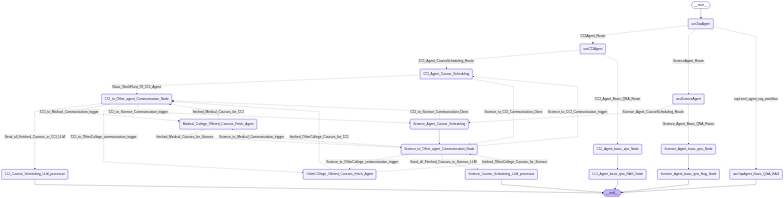

In [325]:
mainWorkingGaph

In [326]:
from IPython.display import display, HTML
import uuid

div_id = f"mermaid-{uuid.uuid4().hex}"

# Get Mermaid code from your graph
mermaid_code = mainWorkingGaph.get_graph().draw_mermaid()

html_code = f"""
<div style="width:2500px; height:auto;">
  <div id="{div_id}" class="mermaid">
    {mermaid_code}
  </div>
</div>

<script type="module">
import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
mermaid.initialize({{ startOnLoad:true }});
mermaid.run({{ 
    nodes: document.querySelectorAll('#{div_id}')
}});
</script>
"""

display(HTML(html_code))



### Now do some dummy call

        "BSc_Mathematics",                               # max words: Science_Course_Core_Study_Plan=538 | Science_Course_Elective_Study_Plan=1 | Science_Offered_Courses_this_semester=1426 | CCI_Offered_Courses_this_semester=2378 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1845  ===> 6187

        "BSc_Chemistry",                                 # max words: Science_Course_Core_Study_Plan=659 | Science_Course_Elective_Study_Plan=1 | Science_Offered_Courses_this_semester=1263 | CCI_Offered_Courses_this_semester=1870 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1740 ===> 5532

        "BSc_Petroleum_Geosciences_and_Remote_Sensing",  # max words: Science_Course_Core_Study_Plan=642 | Science_Course_Elective_Study_Plan=135 | Science_Offered_Courses_this_semester=1166 | CCI_Offered_Courses_this_semester=1 | Medical_College_Offered_courses=3821 | Other_College_Offered_Courses=2183 ===> 3857

        "BSc_Biotechnology",                             # max words: Science_Course_Core_Study_Plan=644 | Science_Course_Elective_Study_Plan=1 | Science_Offered_Courses_this_semester=1148 | CCI_Offered_Courses_this_semester=1 | Medical_College_Offered_courses=382 | Other_College_Offered_Courses=3054 ===>5228

        "BSc_Business_Information_Systems",              # max words: CCI_Course_Core_Study_Plan=506 | CCI_Course_Elective_Study_Plan=198 | CCI_Offered_Courses_this_semester=513 | Science_Offered_Courses_this_semester=261 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1 ===> 1478

        "BSc_IT_Multimedia",                             # max words: CCI_Course_Core_Study_Plan=467 | CCI_Course_Elective_Study_Plan=166 | CCI_Offered_Courses_this_semester=2790 | Science_Offered_Courses_this_semester=104 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1 ===>3527

        "BSc_Computer_Science",                          # max words: CCI_Course_Core_Study_Plan=499 | CCI_Course_Elective_Study_Plan=232 | CCI_Offered_Courses_this_semester=3621 | Science_Offered_Courses_this_semester=1062 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1 ===> 5414

        "BSc_Cybersecurity",                             # max words: CCI_Course_Core_Study_Plan=455 | CCI_Course_Elective_Study_Plan=1 | CCI_Offered_Courses_this_semester=2123 | Science_Offered_Courses_this_semester=2872 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1 ===> 5450

        "BSc_Computer_Engineering",                      # max words: CCI_Course_Core_Study_Plan=747 | CCI_Course_Elective_Study_Plan=355 | CCI_Offered_Courses_this_semester=3696 | Science_Offered_Courses_this_semester=1222 | Medical_College_Offered_courses=1 | Other_College_Offered_Courses=1 ===> 6020

        "BSc_Applied_Physics"                            # max words: Science_Course_Core_Study_Plan=522 | Science_Course_Elective_Study_Plan=560 | Science_Offered_Courses_this_semester=1388 | CCI_Offered_Courses_this_semester=1 | Medical_College_Offered_courses=382 | Other_College_Offered_Courses=72 ===> 2924


In [327]:
#"student_query": "How many credits do I need to complete to graduate if I am majoring in Bio-technology?",
#"student_query": "How many credits do I need to graduate if I am majoring in Computer Science?",
#"student_query": "Can you register 5 courses offerd by university this semester for me? ",
#"student_query": "How many colleges are there in university of sharjah?",
#"student_query": "is UAE Society compulsory course in Computer Science course? ",
#"student_query": "What are the courses needs to take in 6th semester if I am majoring in Computer Science?",
#"student_query": "Can you please schedule the courses for this semester for me? ",
#"student_query": "How many credit have completed till now? ",

# ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]

### Build Some example from CCI: 

In [328]:
Persone_1_initial_state_CCI_Business_Info_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Business_Information_Systems",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me in total of 25 credit Hour? " # "Can you please schedule the courses for this semester for me? ",
}

Persone_2_initial_state_CCI_BSc_Computer_Science_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Sophomore",
    "semester": 3,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Computer_Science",
    "studentAlreadyCompletedCourses": [
        '1501-100', '1440-131', '1430-110', '1430-116', '1501-116', '1420-101', '1420-102', '1440-132', '0104-100', '1501-211', '1502-201', '1501-279', '1440-281', '1501-246', '1501-215',
    ],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me? ",
}

Persone_3_initial_state_CCI_BSc_IT_Multimedia_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Sophomore",
    "semester": 4,
    "yearOfStudy": 2,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Computer_Science",
    "studentAlreadyCompletedCourses": [
        '1501-100', '1440-131', '1430-110', '1430-116', '1501-116', '1420-101', '1420-102', '1440-132', '0104-100', '1501-211', '1502-201', '1501-279', '1440-281', '1501-246', '1501-215', '1502-202', '1501-252', '1440-211', '0204-102', '1501-341', '1501-342', '1501-343', '1501-344', '1501-355',
    ],
    "StudentAlreadyCompletedCredits" : 57,
    "student_query": "Can you please schedule the courses for this semester for me in total of 25 credit Hour? ",
}


result = mainWorkingGaph.invoke(Persone_1_initial_state_CCI_Business_Info_Department)
print(result)
print(result["CCI_FinalScheduler_texts_LLM"].content)



UOS_AgentState_CCIAgent_decision:  CCI_CourseScheduling_advising
Science to CCI communiaction phase !!!
Inside CCI->medical Communication
CCI to Medical college fetch!!!
Inside CCI->other college Communication
CCI to other college fetch!!!
Data are in CCI LLM Processor!!!
{'uid': 'U22106802', 'mensOrWomCampus': 'mens', 'standing': 'Freshman', 'yearOfStudy': 1, 'semester': 1, 'college': 'College of Computing and Informatics', 'department': 'BSc_Business_Information_Systems', 'studentAlreadyCompletedCourses': [], 'StudentAlreadyCompletedCredits': 0, 'student_query': 'Can you please schedule the courses for this semester for me in total of 25 credit Hour? ', 'UOS_AgentState_top_level_decision': 'CCIAgent', 'topLevelAgent_basicConversationOrNot': False, 'UOS_AgentState_CCIAgent_decision': 'CCI_CourseScheduling_advising', 'CCI_Course_Core_Study_Plan': [{'course_code': '0301-120', 'course_title': 'Accounting (1): Financial Accounting', 'prerequisites': [], 'course_semester': 'Year 1 - Semest

### Example from Science College: 

In [336]:
Persone_1_initial_state_Science_Math_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 3,
    "yearOfStudy": 4,
    "college": "College of Science", 
    "department" : "BSc_Mathematics",
    "studentAlreadyCompletedCourses": [
        '0201-102', '1501-100', '1430-115', '1430-116', '1440-131', '0202-112', '1420-101', '1420-102', '1440-132',
        '1440-211', '0104-100', '1501-211', '1440-491'
    ],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me? ",
}

Persone_2_initial_state_Science_Chemistry_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 3,
    "yearOfStudy": 4,
    "college": "College of Science", 
    "department" : "BSc_Chemistry",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "Can you please schedule the courses for this semester for me? ",
}

Persone_3_initial_state_Science_Petroleum_Geosciences_and_Remote_Sensing_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Science", 
    "department" : "BSc_Petroleum_Geosciences_and_Remote_Sensing",
    "studentAlreadyCompletedCourses": [
        '0201-102', '0201-105', '0202-112', '1460-120', '1430-110', '1430-116', '1440-131', '1411-100', '1420-101', '1420-102', '0202-207', '1430-117', 
        '1430-118', '1440-132', '1411-116', '1460-220', '1460-221', '0104-101', '1460-230',
    ],
    "StudentAlreadyCompletedCredits" : 57,
    "student_query": "Can you please schedule the courses offered in this semester for me? ",
}

Persone_4_initial_state_BSc_Biotechnology_Department = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 5,
    "yearOfStudy": 3,
    "college": "College of Science", 
    "department" : "BSc_Biotechnology",
    "studentAlreadyCompletedCourses": [
        '0104-100','0201-102','0202-112','1426-155','1450-101','1450-107','1411-100'

    ],
    "StudentAlreadyCompletedCredits" : 63,
    "student_query": "Can you please schedule the courses offered in this semester for me in total of 15 Credit hour? ",
}




result = mainWorkingGaph.invoke(Persone_1_initial_state_Science_Math_Department)
print(result["Science_FinalScheduler_texts_LLM"].content)

UOS_AgentState_ScienceAgent_decision:  Science_CourseScheduling_advising
Science to CCI communiaction Phase !!!
Inside Science->medical Communication
Science to Medical college fetch!!!
Inside Science->other college commmunicaton
Science to other college fetch!!!
Data are in Science LLM Processor!!!
Data are in Science LLM Processor!!!
course_code:1440-241, course_title:Ordinary Differential Equations I, credit_hours:3, meeting_days:Tuesday, Thursday, meeting_time:08:00 AM - 09:15 AM, campus:UOS Main Campus, section:61
course_code:1440-281, course_title:Introduction to Probability and Statistics, credit_hours:3, meeting_days:Tuesday, Thursday, meeting_time:08:00 AM - 09:15 AM, campus:UOS Men's Campus, section:01
course_code:1440-373, course_title:Graph Theory, credit_hours:3, meeting_days:Monday, Wednesday, meeting_time:12:30 PM - 01:45 PM, campus:UOS Main Campus, section:61
course_code:1501-215, course_title:Data Structures, credit_hours:3, meeting_days:Monday, Wednesday, meeting_time

### Lets do some basic QNA

In [330]:
Persone_1_initial_state_basicQNA = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Business_Information_Systems",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "How many colleges are there in University of Sharjah? "
}

result = mainWorkingGaph.invoke(Persone_1_initial_state_basicQNA)
print(result['basic_Conversation_answer'])

The University of Sharjah has 15 colleges offering more than 132 diverse academic programs. Here are the colleges listed:

1. College of Shari'a and Islamic Studies
2. College of Arts, Humanities & Social Sciences
3. College of Business Administration
4. College of Engineering
5. College of Law
6. College of Fine Arts & Design
7. College of Communication
8. College of Sciences
9. College of Computing and Informatics
10. College of Public Policy 
11. College of Health Sciences
12. College of Dental Medicine
13. College of Medicine
14. College of Pharmacy

There are also several institutes, including the Language Institute, Institute of Leadership in Higher Education, and Disability Resources Center. 

The University of Sharjah has a total of 15 colleges.


In [331]:

Persone_2_initial_state_basicQNA = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Freshman",
    "semester": 1,
    "yearOfStudy": 1,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Business_Information_Systems",
    "studentAlreadyCompletedCourses": [],
    "StudentAlreadyCompletedCredits" : 0,
    "student_query": "is UAE Society compulsory course in Computer Science course? ",
}

result = mainWorkingGaph.invoke(Persone_2_initial_state_basicQNA)
print(result['CCI_Basic_QNA_RAG_Answer'])

UOS_AgentState_CCIAgent_decision:  CCI_Conversation
The UAE Society course (Course # 0204102) is a university elective course, not a compulsory course in the Computer Science program. According to the degree structure, it is a 3-credit hour course that can be taken as one of the university elective courses. Therefore, it is not a required course for Computer Science students, but it can be taken as an elective.
